In [174]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time

## Functions

In [175]:
def all_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'OOB_quantile', 'pb_i_cov', 'pb_ii_cov', 'pb_iii_cov', 'pb_iv_cov',
     'conf_i_cov', 'conf_ii_cov', 'conf_iii_cov', 'conf_iv_cov'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results')):
        if (file.endswith('.npy')):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'sigma': file.split('_')[3][5:],
            'pb_i_cov': [result['pb_i_cov']],
            'pb_ii_cov': [result['pb_ii_cov']],
            'pb_iii_cov': [result['pb_iii_cov']],
            'pb_iv_cov': [result['pb_iv_cov']],
            'conf_i_cov': [result['conf_i_cov']],
            'conf_ii_cov': [result['conf_ii_cov']],
            'conf_iii_cov': [result['conf_iii_cov']],
            'conf_iv_cov': [result['conf_iv_cov']],
            'OOB_quantile': [result['OOB_quantile']],
            'quantile': [result['quantile']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['sigma'] = coverage_df.sigma.astype('category')
    return coverage_df


# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
sigma_values = [0.6, 0.9, 1.7]  # Concentration parameters

Prediction balls

In [176]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
coverage_df=all_coverage_results()
coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
0,68,100,0.9,"[3.0891401942059034, 2.4459927734874727, 1.992...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.97, 0.94]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.996, 0.97]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.946, 0.936]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.978]","[4.167280278509841, 2.3363113847755477, 2.1183..."
1,433,200,1.7,"[4.812382868509768, 3.7782466253924993, 3.1407...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.97, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.95, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.982, 0.932]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.98, 0.912]","[4.518425522693401, 4.296185387043696, 3.19071..."
2,80,500,1.7,"[4.4349272938385385, 3.3810056237236994, 2.858...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.942, 0.884]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.93, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.946, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.948, 0.902]","[4.762754667754213, 3.5358057014261997, 3.0325..."
3,387,50,0.6,"[2.382664885942743, 1.9850965372771587, 1.7932...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.982, 0.968]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[1.0, 0.974, 0.966]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]","[3.319740956607357, 2.4200400486762517, 2.2800..."
4,326,200,0.9,"[2.5387477591697, 1.9271421652667406, 1.685075...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.954, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.936, 0.896]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.94, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.97, 0.932]","[3.032094442680444, 2.036413707053562, 1.76715..."


# TYPE I

In [177]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(coverage_df, sample_sizes, sigma_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_i = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    conf_diccionario_i = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for sigma in sigma_values:
            pb_means = []
            conf_means = []
            coverage_df_N_sigma = coverage_df[(coverage_df['sigma'] == str(sigma)) 
            & (coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in coverage_df['i_cov']
                pb_row_data = coverage_df_N_sigma['pb_i_cov'].apply(lambda df: df[i])
                conf_row_data = coverage_df_N_sigma['conf_i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                pb_row_mean = pb_row_data.mean(axis=0)
                conf_row_mean = conf_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                pb_means.append(pb_row_mean)
                conf_means.append(conf_row_mean)

            pb_diccionario_i['sigma_' + str(sigma)][str(N)] = pb_means
            conf_diccionario_i['sigma_' + str(sigma)][str(N)] = conf_means

    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_i, conf_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
sigma_values = [0.6, 0.9, 1.7]
pb_diccionario_i, conf_diccionario_i = calculate_type_i_coverage(coverage_df = coverage_df, sample_sizes = sample_sizes, sigma_values = sigma_values)
pb_diccionario_i

{'sigma_0.6': {'50': [array([0.984, 0.95 , 0.908]),
   array([0.986, 0.962, 0.886]),
   array([0.992, 0.96 , 0.9  ]),
   array([0.984, 0.948, 0.898]),
   array([0.98 , 0.946, 0.884]),
   array([0.99 , 0.958, 0.89 ]),
   array([0.98 , 0.942, 0.888]),
   array([0.982, 0.952, 0.882]),
   array([0.98 , 0.94 , 0.886]),
   array([0.984, 0.934, 0.874]),
   array([0.984, 0.936, 0.842]),
   array([0.978, 0.942, 0.876]),
   array([0.98 , 0.942, 0.896]),
   array([0.98 , 0.94 , 0.872]),
   array([0.986, 0.958, 0.896]),
   array([0.978, 0.932, 0.866]),
   array([0.984, 0.948, 0.898]),
   array([0.992, 0.954, 0.888]),
   array([0.986, 0.956, 0.9  ]),
   array([0.984, 0.944, 0.872]),
   array([0.986, 0.958, 0.914]),
   array([0.982, 0.938, 0.89 ]),
   array([0.978, 0.942, 0.88 ]),
   array([0.994, 0.962, 0.884]),
   array([0.986, 0.962, 0.89 ]),
   array([0.988, 0.938, 0.878]),
   array([0.984, 0.944, 0.874]),
   array([0.972, 0.938, 0.89 ]),
   array([0.984, 0.946, 0.882]),
   array([0.986, 0.96 , 

Prediction balls

In [178]:
# Prepare data for the DataFrame
pb_rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        pb_row = []
        pb_means = np.mean(pb_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0)
        pb_stds = np.sqrt(np.var(pb_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        pb_formatted_values = [f"{100*pb_means[i]:.2f} ({100*pb_stds[i]:.2f})" for i in range(3)]
        pb_row.extend(pb_formatted_values)
        pb_rows.append(pb_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
pb_df = pd.DataFrame(pb_rows, index=row_index, columns=col_index)

# Display the DataFrame
pb_df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            98.34 (0.51)  94.72 (0.96)  88.46 (1.42)
      100           98.27 (0.52)  94.36 (1.08)  89.66 (1.37)
      200           98.51 (0.56)  94.41 (1.15)  89.43 (1.38)
      500           98.91 (0.49)  94.94 (0.93)  90.17 (1.36)
0.9   50            98.10 (0.52)  93.84 (0.94)  88.09 (1.41)
      100           98.12 (0.53)  94.32 (0.96)  89.37 (1.11)
      200           98.46 (0.64)  94.43 (0.99)  89.48 (1.54)
      500           98.78 (0.49)  94.76 (0.94)  89.54 (1.42)
1.7   50            97.95 (0.68)  93.81 (1.17)  88.02 (1.81)
      100           97.90 (0.67)  93.39 (1.11)  88.35 (1.55)
      200           98.50 (0.50)  94.48 (1.28)  89.66 (1.64)
      500           98.72 (0.53)  94.80 (1.02)  89.74 (1.40)

In [179]:
import pandas as pd
def format_cell(value):
    pb_mean, pb_std = value.split(" ")
    pb_mean = f"{float(pb_mean):.2f}"
    pb_std = pb_std.strip("()")
    pb_std = f"({float(pb_std):.2f})"
    return f"{pb_mean} {pb_std}"

# Apply formatting to all cells
pb_df = pb_df.applymap(format_cell)

pb_latex = pb_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:pbtypeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_78630/4181565808.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_df = pb_df.applymap(format_cell)


Split-conformal

In [180]:
# Prepare data for the DataFrame
conf_rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        conf_row = []
        conf_means = np.mean(conf_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0)
        conf_stds = np.sqrt(np.var(conf_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        conf_formatted_values = [f"{100*conf_means[i]:.2f} ({100*conf_stds[i]:.2f})" for i in range(3)]
        conf_row.extend(conf_formatted_values)
        conf_rows.append(conf_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
conf_df = pd.DataFrame(conf_rows, index=row_index, columns=col_index)

# Display the DataFrame
conf_df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            96.11 (0.74)  92.78 (0.99)  89.08 (1.26)
      100           98.04 (0.58)  94.01 (0.92)  88.02 (1.23)
      200           97.84 (0.68)  93.81 (1.08)  89.02 (1.34)
      500           98.82 (0.41)  94.79 (0.86)  89.86 (1.09)
0.9   50            95.94 (0.70)  92.04 (0.97)  88.15 (1.16)
      100           98.13 (0.68)  94.44 (1.09)  88.59 (1.56)
      200           97.68 (0.77)  93.59 (1.07)  88.92 (1.24)
      500           98.80 (0.42)  94.64 (0.86)  89.48 (1.29)
1.7   50            96.47 (0.81)  92.55 (1.08)  89.00 (1.28)
      100           97.92 (0.71)  94.02 (1.09)  88.06 (1.55)
      200           98.13 (0.65)  94.21 (1.24)  89.49 (1.53)
      500           98.70 (0.55)  94.84 (1.03)  89.82 (1.30)

In [181]:
import pandas as pd
def format_cell(value):
    conf_mean, conf_std = value.split(" ")
    conf_mean = f"{float(conf_mean):.2f}"
    conf_std = conf_std.strip("()")
    conf_std = f"({float(conf_std):.2f})"
    return f"{conf_mean} {conf_std}"

# Apply formatting to all cells
conf_df = conf_df.applymap(format_cell)

conf_latex = conf_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:conftypeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_78630/2688314616.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_df = conf_df.applymap(format_cell)


In [182]:
print(conf_latex)

\begin{table}
\caption{Type I error}
\label{tab:conftypeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 96.11 (0.74) & 92.78 (0.99) & 89.08 (1.26) \\
\textbf{} & \textbf{100} & 98.04 (0.58) & 94.01 (0.92) & 88.02 (1.23) \\
\textbf{} & \textbf{200} & 97.84 (0.68) & 93.81 (1.08) & 89.02 (1.34) \\
\textbf{} & \textbf{500} & 98.82 (0.41) & 94.79 (0.86) & 89.86 (1.09) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 95.94 (0.70) & 92.04 (0.97) & 88.15 (1.16) \\
\textbf{} & \textbf{100} & 98.13 (0.68) & 94.44 (1.09) & 88.59 (1.56) \\
\textbf{} & \textbf{200} & 97.68 (0.77) & 93.59 (1.07) & 88.92 (1.24) \\
\textbf{} & \textbf{500} & 98.80 (0.42) & 94.64 (0.86) & 89.48 (1.29) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 96.47 (0.81) & 92.55 (1.08) & 89.00 (1.28) \\
\textbf{} & \textbf{100} & 97.92 (0.71) & 94.02 (1.09) & 8

# TYPE II

### sigma 0.6

In [183]:
ii_coverage_df_sigma_06_alpha_01 = coverage_df[coverage_df['sigma'] == '0.6'].copy()
ii_coverage_df_sigma_06_alpha_05 = coverage_df[coverage_df['sigma'] == '0.6'].copy()
ii_coverage_df_sigma_06_alpha_1  = coverage_df[coverage_df['sigma'] == '0.6'].copy()

ii_coverage_df_sigma_06_alpha_01['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['pb_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_06_alpha_01['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['conf_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_06_alpha_01['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.6']['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_sigma_06_alpha_01['quantile'] = coverage_df[coverage_df['sigma'] == '0.6']['quantile'].apply(lambda x: x[0])

ii_coverage_df_sigma_06_alpha_05['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['pb_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_06_alpha_05['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['conf_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_06_alpha_05['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.6']['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_sigma_06_alpha_05['quantile'] = coverage_df[coverage_df['sigma'] == '0.6']['quantile'].apply(lambda x: x[1])

ii_coverage_df_sigma_06_alpha_1['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['pb_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_06_alpha_1['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['conf_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_06_alpha_1['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.6']['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_sigma_06_alpha_1['quantile'] = coverage_df[coverage_df['sigma'] == '0.6']['quantile'].apply(lambda x: x[2])

ii_coverage_df_sigma_06_alpha_01.head()
ii_coverage_df_sigma_06_alpha_05.head()
ii_coverage_df_sigma_06_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
3,387,50,0.6,1.793266,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.968,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.966,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]",2.280031
10,441,100,0.6,1.476666,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.942,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.986, 0.972]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.970,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]",2.062124
13,286,50,0.6,1.512419,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.906,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.988, 0.952]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.910,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 0.926]",1.760816
18,482,100,0.6,1.533544,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.962,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.992, 0.97]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.844,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.954, 0.856]",1.160788
20,1,100,0.6,1.351715,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.894,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.976, 0.954]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.844,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.992, 0.974]",1.389688


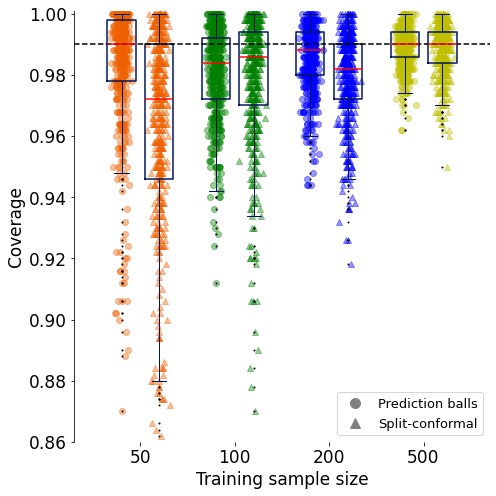

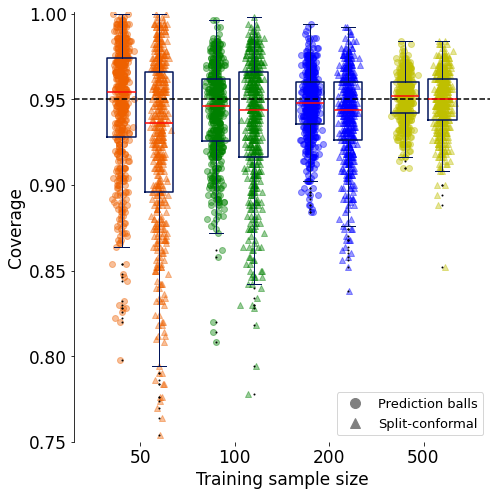

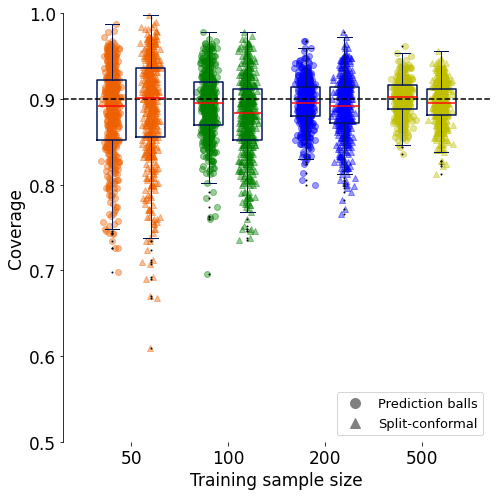

In [184]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [ii_coverage_df_sigma_06_alpha_01, ii_coverage_df_sigma_06_alpha_05, ii_coverage_df_sigma_06_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_ii_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_06_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 0.9

In [185]:
ii_coverage_df_sigma_09_alpha_01 = coverage_df[coverage_df['sigma'] == '0.9'].copy()
ii_coverage_df_sigma_09_alpha_05 = coverage_df[coverage_df['sigma'] == '0.9'].copy()
ii_coverage_df_sigma_09_alpha_1  = coverage_df[coverage_df['sigma'] == '0.9'].copy()

ii_coverage_df_sigma_09_alpha_01['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['pb_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_09_alpha_01['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['conf_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_09_alpha_01['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.9']['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_sigma_09_alpha_01['quantile'] = coverage_df[coverage_df['sigma'] == '0.9']['quantile'].apply(lambda x: x[0])

ii_coverage_df_sigma_09_alpha_05['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['pb_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_09_alpha_05['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['conf_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_09_alpha_05['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.9']['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_sigma_09_alpha_05['quantile'] = coverage_df[coverage_df['sigma'] == '0.9']['quantile'].apply(lambda x: x[1])

ii_coverage_df_sigma_09_alpha_1['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['pb_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_09_alpha_1['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['conf_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_09_alpha_1['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.9']['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_sigma_09_alpha_1['quantile'] = coverage_df[coverage_df['sigma'] == '0.9']['quantile'].apply(lambda x: x[2])

ii_coverage_df_sigma_09_alpha_01.head()
ii_coverage_df_sigma_09_alpha_05.head()
ii_coverage_df_sigma_09_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
0,68,100,0.9,1.992125,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.940,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.996, 0.97]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.936,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.978]",2.118334
4,326,200,0.9,1.685075,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.920,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.936, 0.896]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.904,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.97, 0.932]",1.767159
6,216,50,0.9,1.492459,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.736,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.882, 0.87]","[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.800,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.972, 0.964, 0.952]",1.786063
9,55,200,0.9,1.593654,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.862,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.932,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.958, 0.924]",1.850112
11,447,500,0.9,1.635991,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.916,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.99, 0.968]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.914,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.988, 0.956]",1.670816


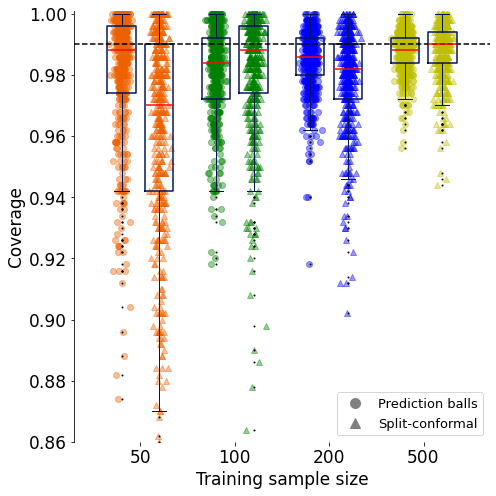

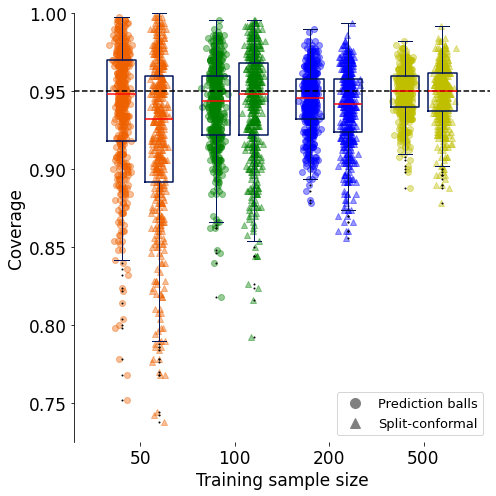

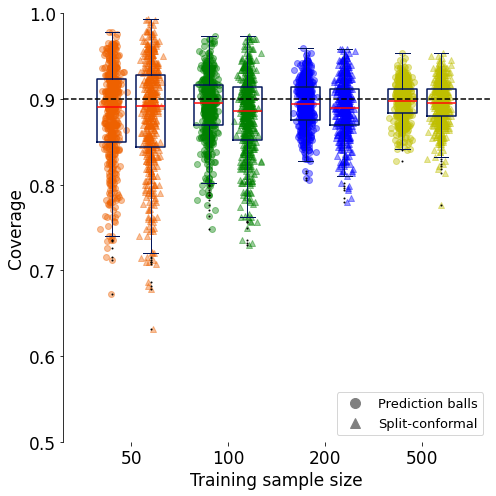

In [186]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [ii_coverage_df_sigma_09_alpha_01, ii_coverage_df_sigma_09_alpha_05, ii_coverage_df_sigma_09_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_ii_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.725, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_09_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 1.7

In [187]:
ii_coverage_df_sigma_17_alpha_01 = coverage_df[coverage_df['sigma'] == '1.7'].copy()
ii_coverage_df_sigma_17_alpha_05 = coverage_df[coverage_df['sigma'] == '1.7'].copy()
ii_coverage_df_sigma_17_alpha_1  = coverage_df[coverage_df['sigma'] == '1.7'].copy()

ii_coverage_df_sigma_17_alpha_01['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['pb_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_17_alpha_01['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['conf_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_17_alpha_01['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.7']['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_sigma_17_alpha_01['quantile'] = coverage_df[coverage_df['sigma'] == '1.7']['quantile'].apply(lambda x: x[0])

ii_coverage_df_sigma_17_alpha_05['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['pb_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_17_alpha_05['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['conf_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_17_alpha_05['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.7']['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_sigma_17_alpha_05['quantile'] = coverage_df[coverage_df['sigma'] == '1.7']['quantile'].apply(lambda x: x[1])

ii_coverage_df_sigma_17_alpha_1['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['pb_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_17_alpha_1['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['conf_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_17_alpha_1['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.7']['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_sigma_17_alpha_1['quantile'] = coverage_df[coverage_df['sigma'] == '1.7']['quantile'].apply(lambda x: x[2])

ii_coverage_df_sigma_17_alpha_01.head()
ii_coverage_df_sigma_17_alpha_05.head()
ii_coverage_df_sigma_17_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
1,433,200,1.7,3.140784,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.934,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.95, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.932,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.98, 0.912]",3.190714
2,80,500,1.7,2.858869,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.884,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.93, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.900,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.948, 0.902]",3.032552
5,21,500,1.7,2.964907,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.902,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.934, 0.886]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.874,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.938, 0.876]",2.857368
7,492,200,1.7,3.014905,"[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.916,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.948, 0.902]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.896,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.946, 0.902]",2.935586
8,352,500,1.7,2.761821,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.884,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.95, 0.886]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.852,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.932, 0.856]",2.711464


In [188]:
ii_coverage_df_alpha_01 = coverage_df.copy()
ii_coverage_df_alpha_05 = coverage_df.copy()
ii_coverage_df_alpha_1  = coverage_df.copy()

ii_coverage_df_alpha_01['OOB_quantile'] = coverage_df['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_alpha_01['quantile'] = coverage_df['quantile'].apply(lambda x: x[0])

ii_coverage_df_alpha_05['OOB_quantile'] = coverage_df['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_alpha_05['quantile'] = coverage_df['quantile'].apply(lambda x: x[1])

ii_coverage_df_alpha_1['OOB_quantile'] = coverage_df['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_alpha_1['quantile'] = coverage_df['quantile'].apply(lambda x: x[2])

ii_coverage_df_alpha_01.head()
ii_coverage_df_alpha_05.head()
ii_coverage_df_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
0,68,100,0.9,1.992125,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.97, 0.94]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.996, 0.97]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.946, 0.936]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.994, 0.978]",2.118334
1,433,200,1.7,3.140784,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.97, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.95, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.982, 0.932]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.98, 0.912]",3.190714
2,80,500,1.7,2.858869,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.942, 0.884]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.93, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.946, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.948, 0.902]",3.032552
3,387,50,0.6,1.793266,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.982, 0.968]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[1.0, 0.974, 0.966]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 1.0, 1.0]",2.280031
4,326,200,0.9,1.685075,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.954, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.936, 0.896]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.94, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.97, 0.932]",1.767159


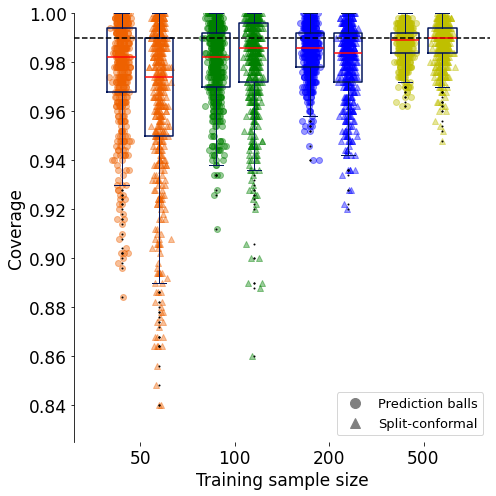

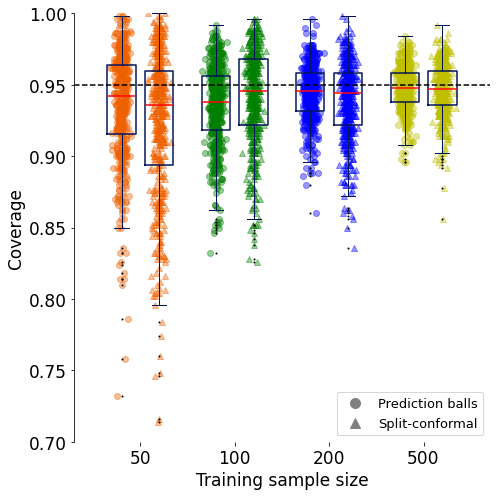

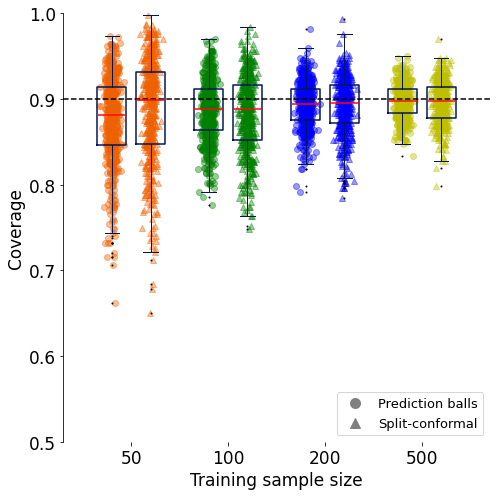

In [189]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [ii_coverage_df_sigma_17_alpha_01, ii_coverage_df_sigma_17_alpha_05, ii_coverage_df_sigma_17_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_ii_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_17_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

0.6


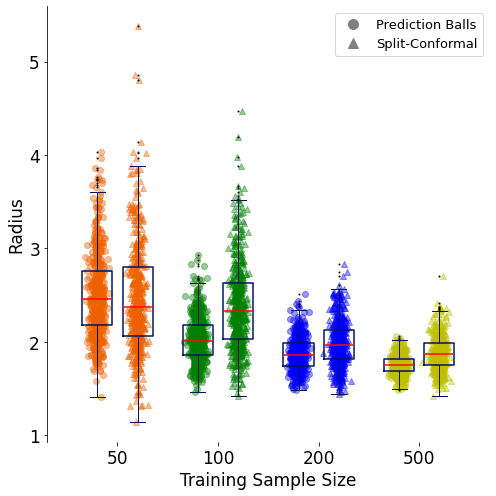

0.6


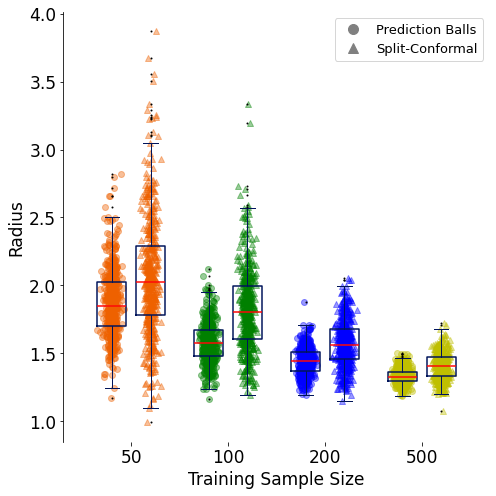

0.6


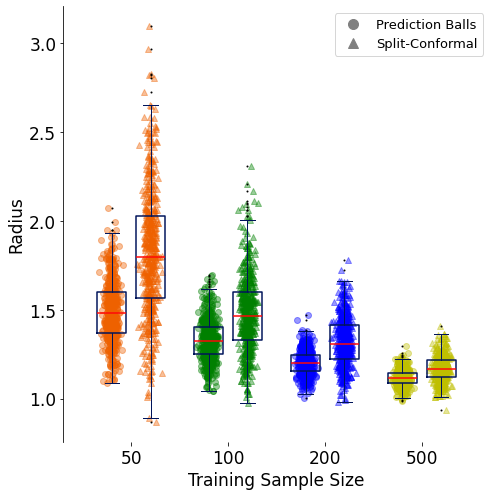

0.9


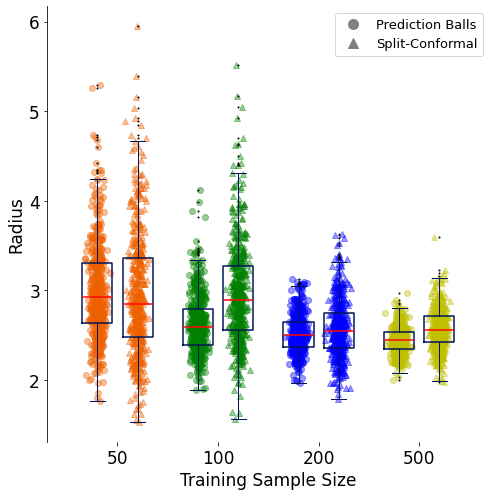

0.9


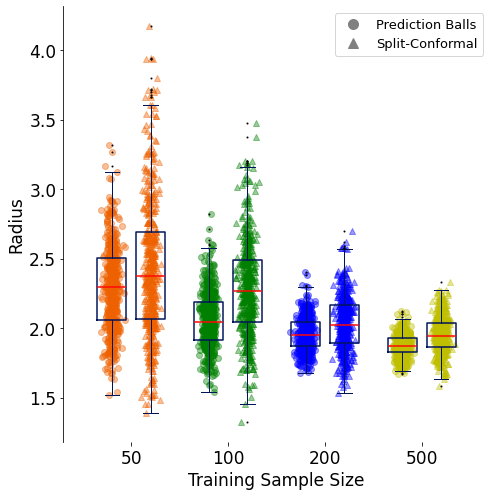

0.9


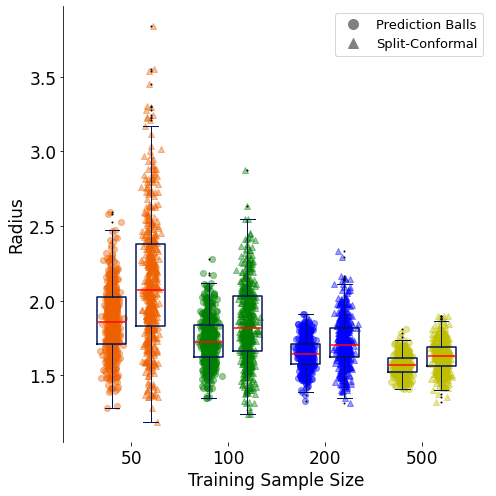

1.7


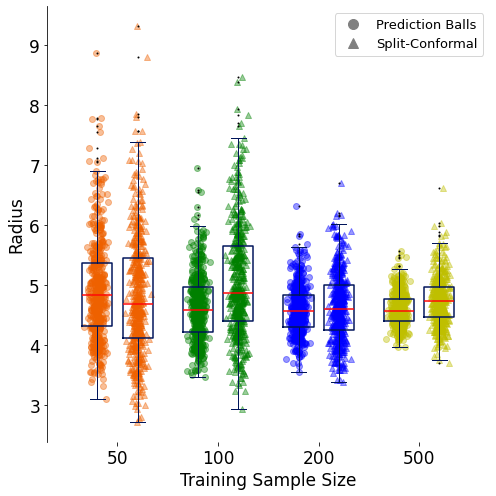

1.7


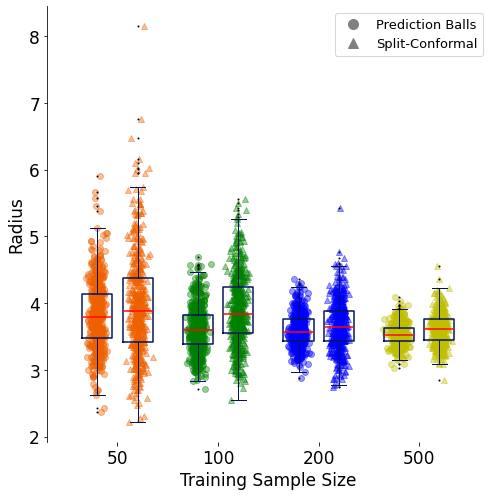

1.7


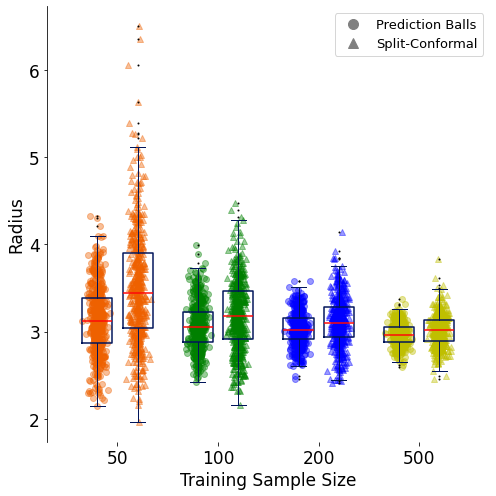

In [207]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def compare_pb_sc_radius(data_list, alpha_levels, sigmas, train_sizes, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) radius across different sigma and alpha values.

    Parameters:
        data_list (list): List of DataFrames containing radii for each alpha level.
        alpha_levels (list): List of significance levels (e.g., [0.01, 0.05, 0.1]).
        sigmas (list): List of sigma values to consider.
        train_sizes (list): List of training sample sizes.
        save_path (str): Path to save the generated plots.
    """
    
    ##### Set style options #####
    boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
    flierprops = dict(marker='o', markersize=1, linestyle='none')
    whiskerprops = dict(color='#00145A')
    capprops = dict(color='#00145A')
    medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

    # Iterate over sigma values
    for sigma in [0.6, 0.9, 1.7]:
        for data, alpha in zip(data_list, alpha_levels):
            fig = plt.figure(facecolor="white", figsize=(7, 7))
            ax = fig.add_subplot(111)
            # Prepare boxplot data
            pb_boxplot_data = [
                data.loc[(data['sigma'] == str(sigma)) & (data['train_size'] == N), 'OOB_quantile']
                for N in train_sizes
            ]
            sc_boxplot_data = [
                data.loc[(data['sigma'] == str(sigma)) & (data['train_size'] == N), 'quantile']
                for N in train_sizes
            ]

            # Set positions for PB and SC boxplots
            positions_pb = np.array(range(len(train_sizes))) - 0.2
            positions_sc = np.array(range(len(train_sizes))) + 0.2
            # Boxplots for PB and SC
            ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)
            
            ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)

            # Scatter plot
            palette = ['#ee6100', 'g', 'b', 'y']  # Colors for each N

            for i, N in enumerate(train_sizes):
                xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
                xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))
                ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
                ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")

            sns.despine(bottom=True)  # Remove right and top axis lines

            ax.set_xticks(range(len(train_sizes)))
            ax.set_xticklabels([str(N) for N in train_sizes], fontsize=17)

            ax.set_xlabel('Training Sample Size', fontsize=17)
            ax.set_ylabel('Radius', fontsize=17)
            ax.tick_params(labelsize=17)
            ax.grid(False)
        
            # Legend
            legend_handles = [
                mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
                mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
            ]
            ax.legend(handles=legend_handles, loc='upper right', fontsize=13)

            fig.tight_layout()
            filename = os.path.join(save_path, f'simulations_euc/pb_vs_conf_radius_vs_sigma_{sigma}_alpha_{str(alpha)[2:]}.pdf')
            fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
            print(sigma)
            plt.show()

compare_pb_sc_radius(
    data_list = [ii_coverage_df_alpha_01, ii_coverage_df_alpha_05, ii_coverage_df_alpha_1],
    alpha_levels=[0.01, 0.05, 0.1],
    sigmas=[0.9],  # Modify as needed
    train_sizes=[50, 100, 200, 500],
    save_path=os.getcwd()  # Change to desired directory
)

# TYPE III

In [191]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(coverage_df, sample_sizes, sigma_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    conf_diccionario_iii = {
    'sigma_0.6': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for sigma in sigma_values:
            pb_means = []
            conf_means = []
            coverage_df_N_sigma = coverage_df[(coverage_df['sigma'] == str(sigma)) 
            & (coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in coverage_df['i_cov']
                pb_row_data = coverage_df_N_sigma['pb_iii_cov'].apply(lambda df: df[i])
                conf_row_data = coverage_df_N_sigma['conf_iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                pb_row_mean = pb_row_data.mean(axis=0)
                conf_row_mean = conf_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                pb_means.append(pb_row_mean)
                conf_means.append(conf_row_mean)

            pb_diccionario_iii['sigma_' + str(sigma)][str(N)] = pb_means
            conf_diccionario_iii['sigma_' + str(sigma)][str(N)] = conf_means

    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_iii, conf_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
sigma_values = [0.6, 0.9, 1.7]
pb_diccionario_iii, conf_diccionario_iii = calculate_type_iii_coverage(coverage_df = coverage_df, sample_sizes = sample_sizes, sigma_values = sigma_values)
pb_diccionario_iii

{'sigma_0.6': {'50': [array([1.   , 0.984, 0.946]),
   array([0.998, 0.992, 0.956]),
   array([0.998, 0.986, 0.952]),
   array([0.994, 0.984, 0.942]),
   array([1.   , 0.992, 0.956]),
   array([0.994, 0.98 , 0.944]),
   array([1.   , 0.992, 0.958]),
   array([1.   , 0.992, 0.956]),
   array([1.   , 0.976, 0.938]),
   array([0.996, 0.982, 0.94 ]),
   array([0.996, 0.98 , 0.942]),
   array([1.   , 0.992, 0.964]),
   array([0.998, 0.99 , 0.958]),
   array([0.996, 0.986, 0.958]),
   array([1.   , 0.98 , 0.944]),
   array([0.996, 0.98 , 0.948]),
   array([0.998, 0.984, 0.938]),
   array([1.   , 0.988, 0.97 ]),
   array([0.996, 0.988, 0.968]),
   array([1.   , 0.984, 0.958]),
   array([0.998, 0.992, 0.948]),
   array([0.994, 0.98 , 0.956]),
   array([0.996, 0.984, 0.952]),
   array([1.   , 0.986, 0.964]),
   array([0.998, 0.984, 0.94 ]),
   array([0.996, 0.982, 0.94 ]),
   array([0.994, 0.976, 0.938]),
   array([0.996, 0.986, 0.96 ]),
   array([0.996, 0.986, 0.95 ]),
   array([0.996, 0.984, 

Prediction balls

In [192]:
# Prepare data for the DataFrame
pb_rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        pb_row = []
        pb_means = np.mean(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        pb_stds = np.sqrt(np.var(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        pb_formatted_values = [f"{100*pb_means[i]:.2f} ({100*pb_stds[i]:.2f})" for i in range(3)]
        pb_row.extend(pb_formatted_values)
        pb_rows.append(pb_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(pb_rows, index=row_index, columns=col_index)

# Display the DataFrame
pb_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            99.76 (0.22)  98.48 (0.53)  95.00 (0.88)
      100           99.62 (0.30)  97.80 (0.70)  94.76 (1.12)
      200           99.44 (0.24)  96.89 (0.75)  93.07 (1.11)
      500           99.39 (0.33)  96.26 (0.72)  92.19 (1.15)
0.9   50            99.29 (0.34)  96.93 (0.71)  92.70 (1.23)
      100           99.10 (0.40)  96.43 (0.78)  92.32 (1.28)
      200           98.98 (0.41)  95.98 (0.98)  91.73 (1.33)
      500           99.08 (0.42)  95.57 (0.85)  90.95 (1.22)
1.7   50            98.49 (0.60)  94.74 (0.98)  89.02 (1.03)
      100           98.32 (0.51)  94.49 (0.88)  89.97 (1.19)
      200           98.66 (0.44)  95.10 (0.98)  90.10 (1.43)
      500           98.87 (0.47)  94.99 (1.06)  90.12 (1.46)

In [193]:
import pandas as pd
def format_cell(value):
    pb_mean, pb_std = value.split(" ")
    pb_mean = f"{float(pb_mean):.2f}"
    pb_std = pb_std.strip("()")
    pb_std = f"({float(pb_std):.2f})"
    return f"{pb_mean} {pb_std}"

# Apply formatting to all cells
pb_df_iii = pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:pbtypeIIIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_78630/2124976488.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_df_iii = pb_df_iii.applymap(format_cell)


In [194]:
print(pb_latex_iii)

\begin{table}
\caption{Type III error}
\label{tab:pbtypeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 99.76 (0.22) & 98.48 (0.53) & 95.00 (0.88) \\
\textbf{} & \textbf{100} & 99.62 (0.30) & 97.80 (0.70) & 94.76 (1.12) \\
\textbf{} & \textbf{200} & 99.44 (0.24) & 96.89 (0.75) & 93.07 (1.11) \\
\textbf{} & \textbf{500} & 99.39 (0.33) & 96.26 (0.72) & 92.19 (1.15) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 99.29 (0.34) & 96.93 (0.71) & 92.70 (1.23) \\
\textbf{} & \textbf{100} & 99.10 (0.40) & 96.43 (0.78) & 92.32 (1.28) \\
\textbf{} & \textbf{200} & 98.98 (0.41) & 95.98 (0.98) & 91.73 (1.33) \\
\textbf{} & \textbf{500} & 99.08 (0.42) & 95.57 (0.85) & 90.95 (1.22) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 98.49 (0.60) & 94.74 (0.98) & 89.02 (1.03) \\
\textbf{} & \textbf{100} & 98.32 (0.51) & 94.49 (0.88) &

Split-conformal

In [195]:
# Prepare data for the DataFrame
conf_rows = []
index = []

for sigma in [0.6, 0.9, 1.7]:
    for N in [50, 100, 200, 500]:
        conf_row = []
        conf_means = np.mean(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        conf_stds = np.sqrt(np.var(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        conf_formatted_values = [f"{100*conf_means[i]:.2f} ({100*conf_stds[i]:.2f})" for i in range(3)]
        conf_row.extend(conf_formatted_values)
        conf_rows.append(conf_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
conf_df_iii = pd.DataFrame(conf_rows, index=row_index, columns=col_index)

# Display the DataFrame
conf_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.6   50            99.34 (0.36)  97.85 (0.65)  96.07 (0.88)
      100           99.64 (0.28)  98.40 (0.49)  95.43 (0.89)
      200           99.40 (0.31)  97.20 (0.67)  93.72 (1.09)
      500           99.51 (0.29)  96.80 (0.78)  92.70 (1.20)
0.9   50            98.18 (0.59)  95.80 (0.88)  93.46 (0.95)
      100           99.27 (0.32)  96.91 (0.73)  92.54 (1.08)
      200           98.89 (0.43)  96.14 (0.89)  91.92 (1.24)
      500           99.13 (0.44)  95.96 (0.75)  91.62 (1.14)
1.7   50            97.54 (0.67)  94.20 (0.83)  91.06 (1.23)
      100           98.53 (0.50)  95.40 (0.83)  90.22 (1.34)
      200           98.30 (0.60)  94.49 (1.04)  89.88 (1.26)
      500           98.93 (0.44)  95.13 (1.07)  90.14 (1.39)

In [196]:
import pandas as pd
def format_cell(value):
    conf_mean, conf_std = value.split(" ")
    conf_mean = f"{float(conf_mean):.2f}"
    conf_std = conf_std.strip("()")
    conf_std = f"({float(conf_std):.2f})"
    return f"{conf_mean} {conf_std}"

# Apply formatting to all cells
conf_df_iii = conf_df_iii.applymap(format_cell)

conf_latex_iii = conf_df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:conftypeIIIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_78630/998839332.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_df_iii = conf_df_iii.applymap(format_cell)


In [197]:
print(conf_latex_iii)

\begin{table}
\caption{Type III error}
\label{tab:conftypeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.6}} & \textbf{50} & 99.34 (0.36) & 97.85 (0.65) & 96.07 (0.88) \\
\textbf{} & \textbf{100} & 99.64 (0.28) & 98.40 (0.49) & 95.43 (0.89) \\
\textbf{} & \textbf{200} & 99.40 (0.31) & 97.20 (0.67) & 93.72 (1.09) \\
\textbf{} & \textbf{500} & 99.51 (0.29) & 96.80 (0.78) & 92.70 (1.20) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{0.9}} & \textbf{50} & 98.18 (0.59) & 95.80 (0.88) & 93.46 (0.95) \\
\textbf{} & \textbf{100} & 99.27 (0.32) & 96.91 (0.73) & 92.54 (1.08) \\
\textbf{} & \textbf{200} & 98.89 (0.43) & 96.14 (0.89) & 91.92 (1.24) \\
\textbf{} & \textbf{500} & 99.13 (0.44) & 95.96 (0.75) & 91.62 (1.14) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.7}} & \textbf{50} & 97.54 (0.67) & 94.20 (0.83) & 91.06 (1.23) \\
\textbf{} & \textbf{100} & 98.53 (0.50) & 95.40 (0.83)

# Type IV

### sigma 0.6

In [198]:
iv_coverage_df_sigma_06_alpha_01 = coverage_df[coverage_df['sigma'] == '0.6'].copy()
iv_coverage_df_sigma_06_alpha_05 = coverage_df[coverage_df['sigma'] == '0.6'].copy()
iv_coverage_df_sigma_06_alpha_1  = coverage_df[coverage_df['sigma'] == '0.6'].copy()

iv_coverage_df_sigma_06_alpha_01['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['pb_iv_cov'].apply(lambda x: x[0])
iv_coverage_df_sigma_06_alpha_01['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['conf_iv_cov'].apply(lambda x: x[0])

iv_coverage_df_sigma_06_alpha_05['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['pb_iv_cov'].apply(lambda x: x[1])
iv_coverage_df_sigma_06_alpha_05['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['conf_iv_cov'].apply(lambda x: x[1])

iv_coverage_df_sigma_06_alpha_1['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['pb_iv_cov'].apply(lambda x: x[2])
iv_coverage_df_sigma_06_alpha_1['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.6']['conf_iv_cov'].apply(lambda x: x[2])

iv_coverage_df_sigma_06_alpha_01.head()
iv_coverage_df_sigma_06_alpha_05.head()
iv_coverage_df_sigma_06_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
3,387,50,0.6,"[2.382664885942743, 1.9850965372771587, 1.7932...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.982, 0.968]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",1.000,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[1.0, 0.974, 0.966]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",1.000,"[3.319740956607357, 2.4200400486762517, 2.2800..."
10,441,100,0.6,"[2.163653885515941, 1.7081402751006813, 1.4766...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.974, 0.942]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.972,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.992, 0.97]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",1.000,"[3.3942418688542295, 2.5686392131850493, 2.062..."
13,286,50,0.6,"[3.3667782059044327, 1.7990952510648421, 1.512...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.944, 0.906]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.952,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.988, 0.91]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.926,"[2.634875694647064, 2.550953054403436, 1.76081..."
18,482,100,0.6,"[2.1966586862546755, 1.8202894160554681, 1.533...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.98, 0.962]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.970,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.936, 0.844]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.856,"[2.3002415980219766, 1.5447299060454742, 1.160..."
20,1,100,0.6,"[1.7288542986111926, 1.5183625568132926, 1.351...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.962, 0.936, 0.894]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.954,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.958, 0.912, 0.844]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.974,"[1.8956708676831353, 1.6115745345331165, 1.389..."


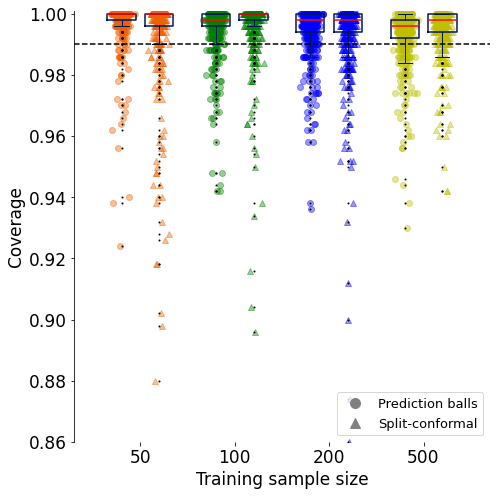

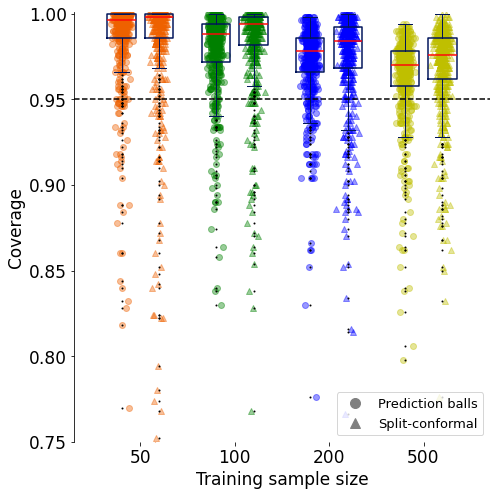

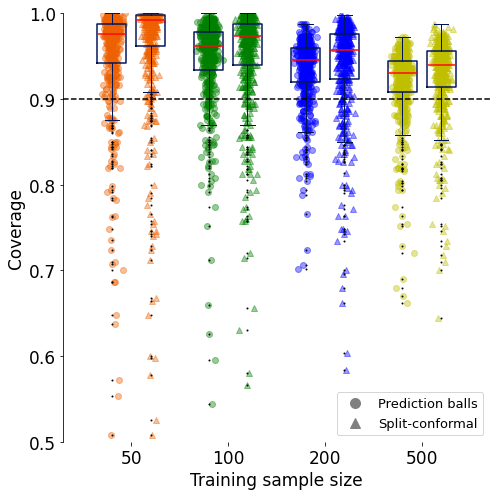

In [199]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [iv_coverage_df_sigma_06_alpha_01, iv_coverage_df_sigma_06_alpha_05, iv_coverage_df_sigma_06_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_iv_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_06_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 0.9

In [200]:
iv_coverage_df_sigma_09_alpha_01 = coverage_df[coverage_df['sigma'] == '0.9'].copy()
iv_coverage_df_sigma_09_alpha_05 = coverage_df[coverage_df['sigma'] == '0.9'].copy()
iv_coverage_df_sigma_09_alpha_1  = coverage_df[coverage_df['sigma'] == '0.9'].copy()

iv_coverage_df_sigma_09_alpha_01['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['pb_iv_cov'].apply(lambda x: x[0])
iv_coverage_df_sigma_09_alpha_01['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['conf_iv_cov'].apply(lambda x: x[0])

iv_coverage_df_sigma_09_alpha_05['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['pb_iv_cov'].apply(lambda x: x[1])
iv_coverage_df_sigma_09_alpha_05['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['conf_iv_cov'].apply(lambda x: x[1])

iv_coverage_df_sigma_09_alpha_1['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['pb_iv_cov'].apply(lambda x: x[2])
iv_coverage_df_sigma_09_alpha_1['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.9']['conf_iv_cov'].apply(lambda x: x[2])

iv_coverage_df_sigma_09_alpha_01.head()
iv_coverage_df_sigma_09_alpha_05.head()
iv_coverage_df_sigma_09_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
0,68,100,0.9,"[3.0891401942059034, 2.4459927734874727, 1.992...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.97, 0.94]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.970,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.946, 0.936]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.978,"[4.167280278509841, 2.3363113847755477, 2.1183..."
4,326,200,0.9,"[2.5387477591697, 1.9271421652667406, 1.685075...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.954, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.896,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.94, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.932,"[3.032094442680444, 2.036413707053562, 1.76715..."
6,216,50,0.9,"[3.333705014666386, 1.5220400726527106, 1.4924...","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.752, 0.736]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.870,"[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.848, 0.818, 0.8]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.952,"[1.9905702221167219, 1.8800045973714954, 1.786..."
9,55,200,0.9,"[2.408303658945662, 1.8816740211279055, 1.5936...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.926, 0.862]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.934,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.978, 0.966, 0.932]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.924,"[2.4939891726359833, 2.1356412538602303, 1.850..."
11,447,500,0.9,"[2.468537157962583, 1.9657421084129467, 1.6359...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.968,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.964, 0.914]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.956,"[2.684167598921647, 2.1155537190322207, 1.6708..."


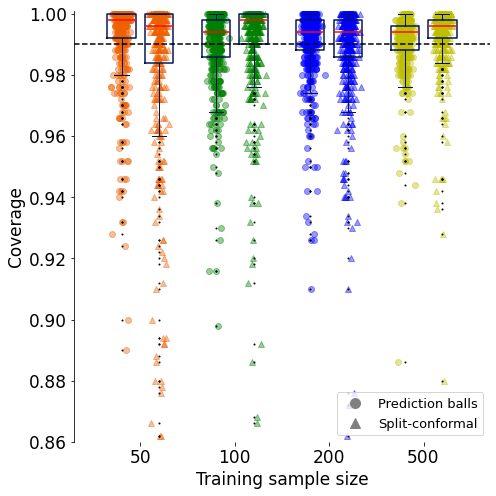

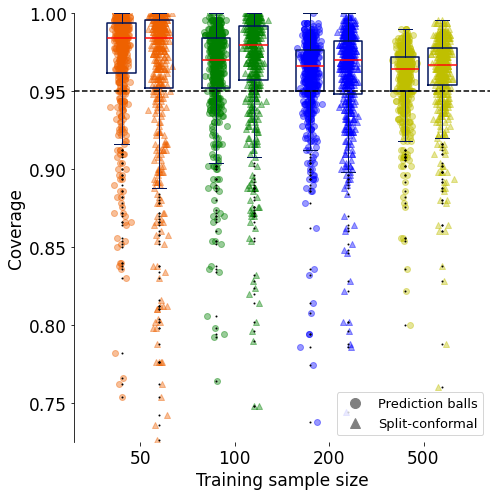

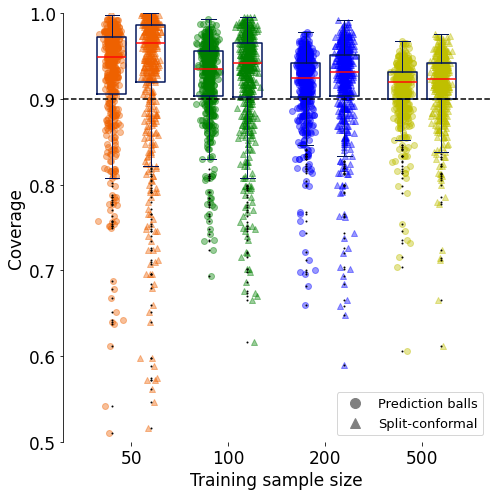

In [201]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [iv_coverage_df_sigma_09_alpha_01, iv_coverage_df_sigma_09_alpha_05, iv_coverage_df_sigma_09_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_iv_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.725, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_09_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 1.7

In [202]:
iv_coverage_df_sigma_17_alpha_01 = coverage_df[coverage_df['sigma'] == '1.7'].copy()
iv_coverage_df_sigma_17_alpha_05 = coverage_df[coverage_df['sigma'] == '1.7'].copy()
iv_coverage_df_sigma_17_alpha_1  = coverage_df[coverage_df['sigma'] == '1.7'].copy()

iv_coverage_df_sigma_17_alpha_01['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['pb_iv_cov'].apply(lambda x: x[0])
iv_coverage_df_sigma_17_alpha_01['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['conf_iv_cov'].apply(lambda x: x[0])

iv_coverage_df_sigma_17_alpha_05['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['pb_iv_cov'].apply(lambda x: x[1])
iv_coverage_df_sigma_17_alpha_05['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['conf_iv_cov'].apply(lambda x: x[1])

iv_coverage_df_sigma_17_alpha_1['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['pb_iv_cov'].apply(lambda x: x[2])
iv_coverage_df_sigma_17_alpha_1['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.7']['conf_iv_cov'].apply(lambda x: x[2])

iv_coverage_df_sigma_17_alpha_01.head()
iv_coverage_df_sigma_17_alpha_05.head()
iv_coverage_df_sigma_17_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,quantile
1,433,200,1.7,"[4.812382868509768, 3.7782466253924993, 3.1407...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.97, 0.934]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.904,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.982, 0.932]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.912,"[4.518425522693401, 4.296185387043696, 3.19071..."
2,80,500,1.7,"[4.4349272938385385, 3.3810056237236994, 2.858...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.942, 0.884]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.878,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.946, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.902,"[4.762754667754213, 3.5358057014261997, 3.0325..."
5,21,500,1.7,"[4.7597785525904115, 3.5904309516542736, 2.964...","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.99, 0.954, 0.902]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.886,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.982, 0.946, 0.874]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.876,"[4.6891105780877815, 3.592847820758954, 2.8573..."
7,492,200,1.7,"[4.491826249519258, 3.4260363235578937, 3.0149...","[[0.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.952, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.902,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.948, 0.896]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.902,"[5.960365546288406, 3.5003699702807505, 2.9355..."
8,352,500,1.7,"[5.033769778870396, 3.3659661242432217, 2.7618...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.942, 0.884]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.886,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.926, 0.852]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.856,"[5.108546854668583, 3.28280830384353, 2.711464..."


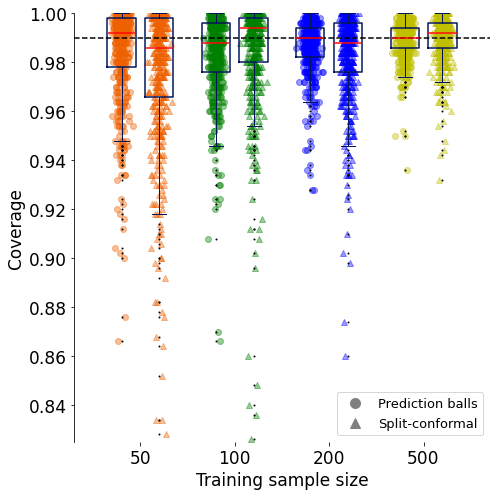

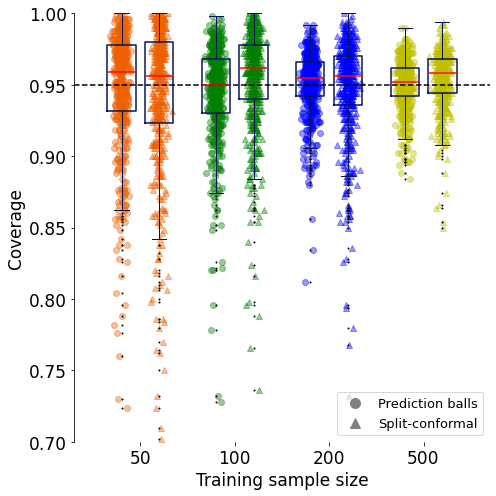

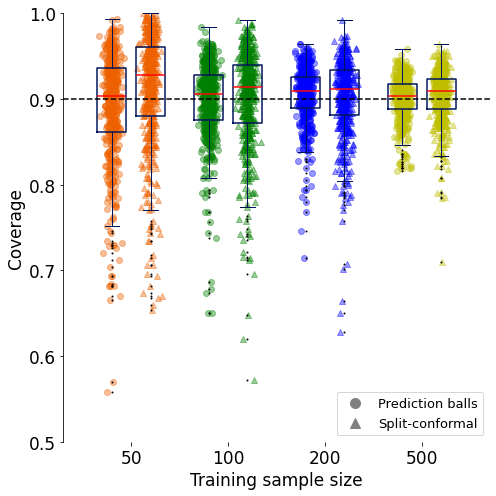

In [203]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [iv_coverage_df_sigma_17_alpha_01, iv_coverage_df_sigma_17_alpha_05, iv_coverage_df_sigma_17_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_iv_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_17_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()